# FaceForge — Phase 0: Environment and Data Pipeline

**Goal:** Install dependencies, download CelebA, build the dataset class, visualize a batch, and compute attribute statistics.

Run all cells top-to-bottom. Each cell is self-contained and safe to re-run after session resume.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q ftfy clip-anytorch scikit-image matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.8 MB/s eta 0:00:00


In [3]:
import os, subprocess
import sys
import torch, torchvision

# All persistent data lives here. Change if your Drive layout differs.
DRIVE_ROOT   = '/content/drive/MyDrive/FaceForge'
DATA_ROOT    = os.path.join(DRIVE_ROOT, 'data')       # CelebA lives here
CKPT_ROOT    = os.path.join(DRIVE_ROOT, 'checkpoints')
REPO_ROOT    = '/content/FaceForge'                   # cloned repo

os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(CKPT_ROOT, exist_ok=True)

print(f'Drive mounted. Data root : {DATA_ROOT}')
print(f'Checkpoint root          : {CKPT_ROOT}')
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.version.cuda}')
print(f'GPU      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

Drive mounted. Data root : /content/drive/MyDrive/FaceForge/data
Checkpoint root          : /content/drive/MyDrive/FaceForge/checkpoints
PyTorch  : 2.10.0+cu128
CUDA     : 12.8
GPU      : Tesla T4


In [4]:
REPO_URL = 'https://github.com/janampatel/FaceForge.git'

if os.path.isdir(REPO_ROOT):
    print('Repo exists — pulling latest...')
    subprocess.run(['git', '-C', REPO_ROOT, 'pull'], check=True)
else:
    print('Cloning repo...')
    subprocess.run(['git', 'clone', REPO_URL, REPO_ROOT], check=True)

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print('Repo ready at', REPO_ROOT)

Cloning repo...
Repo ready at /content/FaceForge


## Download CelebA

**Primary path:** `torchvision.datasets.CelebA` with `download=True`.  
**Fallback:** If Google Drive throttles the download, follow the manual instructions printed below.

In [5]:
from data_pipeline import celeba_is_downloaded
import torchvision

if celeba_is_downloaded(DATA_ROOT):
    print('CelebA already downloaded — skipping.')
else:
    print('Attempting automatic download via torchvision...')
    print('This can fail with a Google Drive quota error. If it does, see fallback below.\n')
    torchvision.datasets.CelebA(
        root=DATA_ROOT,
        split='train',
        target_type='attr',
        download=True
    )

Attempting automatic download via torchvision...
This can fail with a Google Drive quota error. If it does, see fallback below.



Downloading...
From (original): https://drive.google.com/uc?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM
From (redirected): https://drive.usercontent.google.com/download?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM&confirm=t&uuid=ae6b2a0e-b20c-4ae6-bd3b-ac40a8e79c8b
To: /content/drive/MyDrive/FaceForge/data/celeba/img_align_celeba.zip
100%|██████████| 1.44G/1.44G [00:17<00:00, 82.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pblRyaVFSWGxPY0U
To: /content/drive/MyDrive/FaceForge/data/celeba/list_attr_celeba.txt
100%|██████████| 26.7M/26.7M [00:00<00:00, 73.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS
To: /content/drive/MyDrive/FaceForge/data/celeba/identity_CelebA.txt
100%|██████████| 3.42M/3.42M [00:00<00:00, 14.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pbThiMVRxWXZ4dU0
To: /content/drive/MyDrive/FaceForge/data/celeba/list_bbox_celeba.txt
100%|██████████| 6.08M/6.08M [00:00<00:00, 27.9MB/s]
Downloading...
From:

## Build DataLoader and Verify Shapes

In [6]:
from data_pipeline import make_dataloader, SELECTED_ATTRS, NUM_ATTRS
import torch

train_loader = make_dataloader(
    root=DATA_ROOT,
    split='train',
    download=False,
    batch_size=64,
    num_workers=2
)

images, attrs = next(iter(train_loader))

print(f'Image batch : shape={images.shape}  dtype={images.dtype}  '
      f'min={images.min():.2f}  max={images.max():.2f}')
print(f'Attr  batch : shape={attrs.shape}   dtype={attrs.dtype}')
print(f'Selected attributes ({NUM_ATTRS}): {SELECTED_ATTRS}')

# Hard assertions — these must pass before proceeding
assert images.shape == (64, 3, 64, 64), f'Bad image shape: {images.shape}'
assert attrs.shape  == (64, 18),        f'Bad attr shape: {attrs.shape}'
assert attrs.dtype  == torch.float32,   f'Attrs should be float32, got {attrs.dtype}'
assert images.min() >= -1.01 and images.max() <= 1.01, 'Images not in [-1, 1]'

Image batch : shape=torch.Size([64, 3, 64, 64])  dtype=torch.float32  min=-1.00  max=1.00
Attr  batch : shape=torch.Size([64, 18])   dtype=torch.float32
Selected attributes (18): ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Black_Hair', 'Blond_Hair', 'Brown_Hair', 'Bushy_Eyebrows', 'Eyeglasses', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'No_Beard', 'Pale_Skin', 'Smiling', 'Young']


## Visualize a 4×4 Image Grid

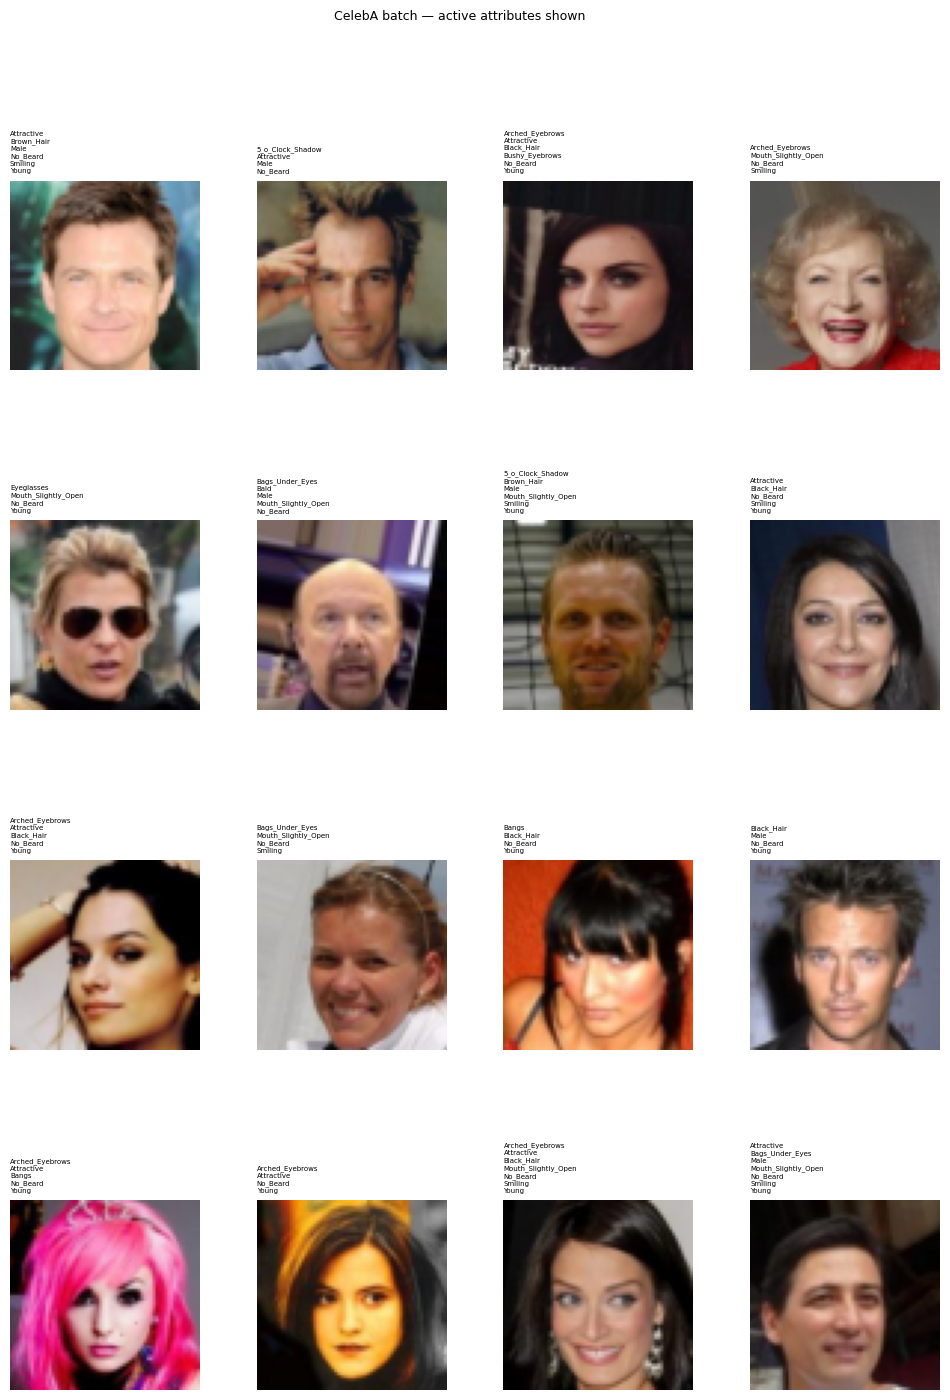

Saved grid to /content/drive/MyDrive/FaceForge/phase0_batch_grid.png


In [7]:
from data_pipeline import visualize_batch

grid_save_path = os.path.join(DRIVE_ROOT, 'phase0_batch_grid.png')

visualize_batch(images, attrs, n_rows=4, n_cols=4)

# Also save to Drive for reference
visualize_batch(images, attrs, n_rows=4, n_cols=4, save_path=grid_save_path)

## Attribute Statistics

Computes the mean (prevalence) and std of each attribute across all 162,770 training images.
Useful for understanding class imbalance before training.

In [ ]:
from data_pipeline import compute_attr_statistics, print_attr_statistics
import torch

# Use a stats-only loader: no shuffle, larger batch for speed
stats_loader = make_dataloader(
    root=DATA_ROOT, split='train', download=False,
    batch_size=256, num_workers=2
)

stats = compute_attr_statistics(stats_loader)
print_attr_statistics(stats)

# Save stats to Drive
stats_path = os.path.join(DRIVE_ROOT, 'phase0_attr_stats.pt')
torch.save(stats, stats_path)
print(f'\nStats saved to {stats_path}')

Computing attribute statistics (this may take a minute)...


## Validation

In [ ]:
import torch
from data_pipeline import make_dataloader, NUM_ATTRS

# Check 1: DataLoader iterates 3 batches without error
loader = make_dataloader(root=DATA_ROOT, split='train',
                         download=False, batch_size=64, num_workers=2)
for i, (imgs, atts) in enumerate(loader):
    if i == 2:
        break
print('DataLoader iterated 3 batches without error')

# Check 2: Image shape and range
assert imgs.shape[1:] == (3, 64, 64)
assert imgs.min() >= -1.01 and imgs.max() <= 1.01
print(f'Image shape {imgs.shape}, range [{imgs.min():.2f}, {imgs.max():.2f}]')

# Check 3: Attribute shape and dtype
assert atts.shape[1] == NUM_ATTRS and atts.dtype == torch.float32
print(f'Attribute shape {atts.shape}, dtype {atts.dtype}')

# Check 4: Stats file exists
stats_path = os.path.join(DRIVE_ROOT, 'phase0_attr_stats.pt')
assert os.path.exists(stats_path), f'Stats not found at {stats_path}'
print(f'Attribute stats saved at {stats_path}')

# Check 5: Grid image exists
grid_path = os.path.join(DRIVE_ROOT, 'phase0_batch_grid.png')
assert os.path.exists(grid_path), f'Grid image not found at {grid_path}'
print(f'Batch grid saved at {grid_path}')